![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

<div style="float: right; font-size: small;">
    Erstellt von Fakher Ahmed für Data Science. Institut by Fabian Rappert
</div>

# **Einführung in Seaborn**

Warum Seaborn, wenn es Matplotlib schon gibt?

✅ Einfachere Syntax
✅ Attraktive Standard-Stile
✅ Integrierte Statistik-Funktionen



---

## Seaborn-Plot-Typen

[Beispiele](https://seaborn.pydata.org/examples/index.html)

### **1️⃣ Verteilungsplots**
Zur Visualisierung von Verteilungen numerischer Daten:

- `histplot` – Histogramm der Datenverteilung
- `kdeplot` – Kernel-Dichteschätzung (KDE)
- `ecdfplot` – Empirische Verteilungsfunktion (ECDF)
- `rugplot` – Markierungen entlang der Achse zur Anzeige einzelner Werte

### **2️⃣ Statistische Zusammenhänge**
Zur Analyse von Beziehungen zwischen zwei Variablen:

- `scatterplot` – Punktwolke zur Visualisierung von Korrelationen
- `lineplot` – Liniendiagramm zur Darstellung von Trends oder Zeitreihen
- `relplot` – Flexibles Werkzeug zur Erstellung von Scatter- und Lineplots mit zusätzlichen Gruppierungsoptionen

### **3️⃣ Kategorische Plots**
Zur Visualisierung von kategorialen Daten:

- **Kategorische Scatterplots:**
  - `stripplot` – Punkte nebeneinander dargestellt (Standard)
  - `swarmplot` – Punkte mit Kollisionserkennung, um Überlappungen zu vermeiden

- **Kategorische Verteilungsplots:**
  - `boxplot` – Box-Whisker-Plot zur Verteilungsanalyse
  - `violinplot` – Kombination aus Boxplot und KDE
  - `boxenplot` – Erweiterter Boxplot für viele Datenpunkte

- **Kategorische Schätzungsplots:**
  - `pointplot` – Punktdiagramm mit Mittelwerten und Fehlerbalken
  - `barplot` – Balkendiagramm zur Darstellung von Mittelwerten
  - `countplot` – Balkendiagramm für Häufigkeitsverteilungen

- **Flexibler Kategorischer Plot:**
  - `catplot` – Kategorische Plots mit mehreren Gruppierungsoptionen

### **4️⃣ Regressionsplots**
Zur Darstellung von Regressionsmodellen:

- `regplot` – Streudiagramm mit Regressionslinie
- `lmplot` – Erweiterter Regressionsplot mit Gruppierungsoptionen

---


In [5]:
## Installation (falls noch nicht installiert)
# !pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns

Der `tips`-Datensatz aus der Python-Bibliothek **Seaborn** enthält Informationen zu Restaurantrechnungen und Trinkgeldern.

Der `tips`-Datensatz umfasst **244 Beobachtungen** und **7 Variablen**, die verschiedene Aspekte von Restaurantbesuchen erfassen:

| Spalte      | Typ     | Beschreibung |
|------------|--------|-------------|
| `total_bill` | float | Gesamtrechnung in US-Dollar |
| `tip` | float | Gegebenes Trinkgeld in US-Dollar |
| `sex` | string | Geschlecht der bedienenden Person (`Male`, `Female`) |
| `smoker` | string | Ob die bedienende Person raucht (`Yes`, `No`) |
| `day` | string | Wochentag des Besuchs (`Thur`, `Fri`, `Sat`, `Sun`) |
| `time` | string | Tageszeit des Besuchs (`Lunch`, `Dinner`) |
| `size` | int | Anzahl der Personen am Tisch |



In [7]:
# Beispiel-Datensatz laden
df = sns.load_dataset("tips")

# Überblick über den Datensatz
display(df)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2



Seaborn-Theme setzen mit [set_theme](https://seaborn.pydata.org/generated/seaborn.set_theme.html) (z. B. "whitegrid"):

In [9]:
sns.set_theme(style="whitegrid")

## Wichtige Plots in Seaborn

### Verteilungsplots

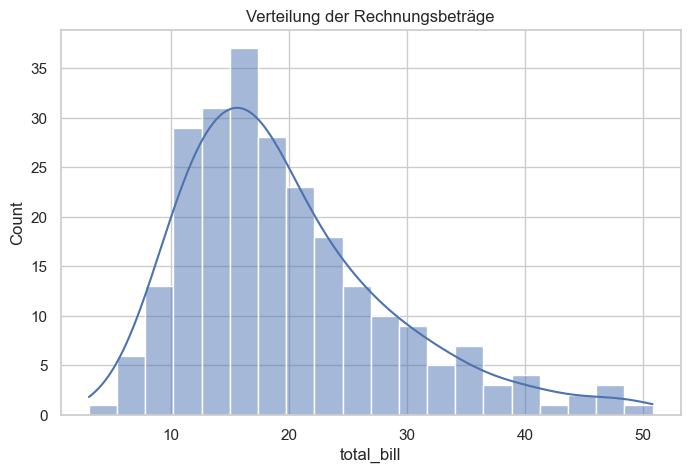

In [11]:
# Erstellen einer neuen Abbildung mit spezifischer Größe
plt.figure(figsize=(8, 5))
# figsize=(8,5) setzt die Breite auf 8 und die Höhe auf 5 Zoll,
# um das Diagramm besser sichtbar zu machen.

# Erstellen eines Histogramms der Spalte "total_bill"
sns.histplot(df["total_bill"], bins=20, kde=True)
# bins=20 → Teilt den Wertebereich von "total_bill" in 20 Intervalle (Bins) auf.
# kde=True → Fügt eine Dichtekurve (Kernel Density Estimation, KDE) hinzu, um die Verteilung der Werte zu glätten.

# Setzen eines Titels für das Diagramm
plt.title("Verteilung der Rechnungsbeträge")

# Anzeigen des Diagramms
plt.show()

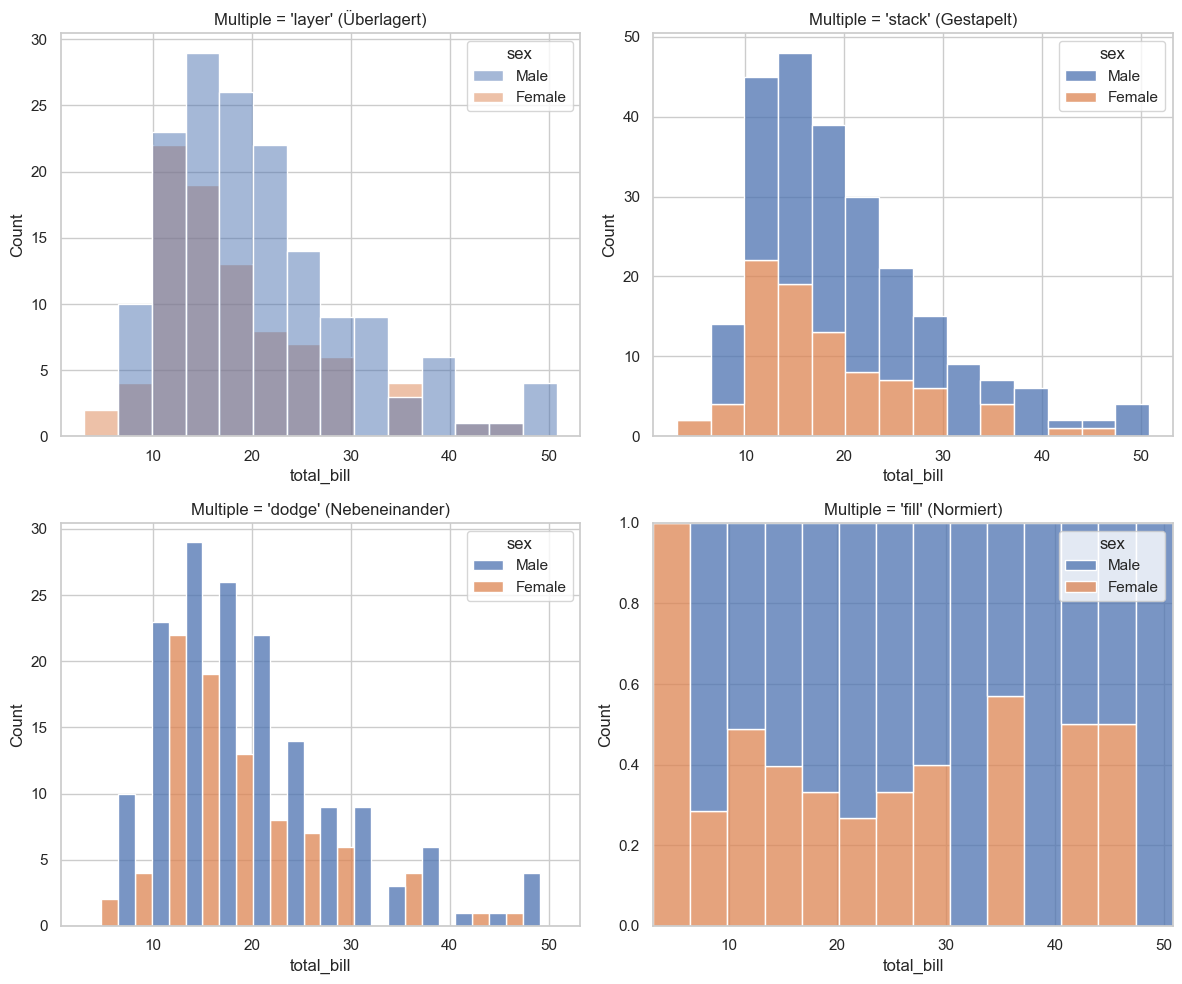

In [12]:
# Erstellen einer 2x2-Anordnung von Histogrammen
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Standard (überlagert)
sns.histplot(x="total_bill", hue="sex", data=df, multiple="layer", alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Multiple = 'layer' (Überlagert)")

# Gestapelte Balken
sns.histplot(x="total_bill", hue="sex", data=df, multiple="stack", ax=axes[0, 1])
axes[0, 1].set_title("Multiple = 'stack' (Gestapelt)")

# Nebeneinanderliegende Balken
sns.histplot(x="total_bill", hue="sex", data=df, multiple="dodge", ax=axes[1, 0])
axes[1, 0].set_title("Multiple = 'dodge' (Nebeneinander)")

# Normiert (Fläche = 1)
sns.histplot(x="total_bill", hue="sex", data=df, multiple="fill", ax=axes[1, 1])
axes[1, 1].set_title("Multiple = 'fill' (Normiert)")

# Layout-Anpassung für bessere Sichtbarkeit
plt.tight_layout()
plt.show()

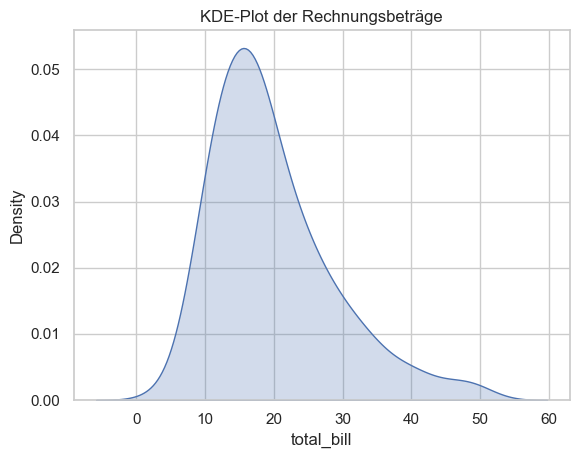

In [13]:
# KDE-Plot (Dichte-Schätzung)

# Erstellen eines KDE-Plots (Kernel Density Estimation)
sns.kdeplot(df["total_bill"], fill=True)
# fill=True → Füllt die Fläche unter der Dichtekurve aus, um die Visualisierung ansprechender zu gestalten.

# Setzen eines Titels für das Diagramm
plt.title("KDE-Plot der Rechnungsbeträge")

# Anzeigen des Diagramms
plt.show()

<Axes: xlabel='total_bill'>

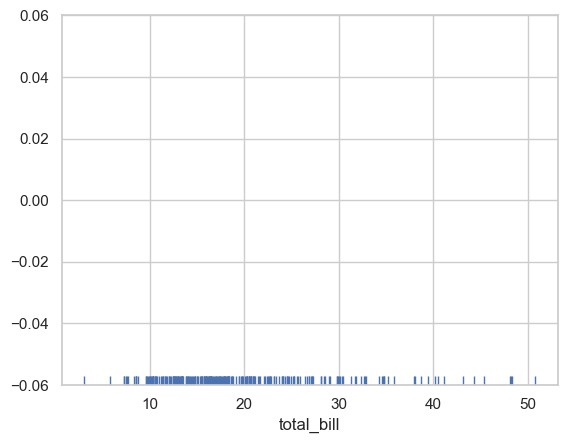

In [14]:
# Markierungen entlang der Achse zur Anzeige einzelner Werte
sns.rugplot(df["total_bill"])

<Axes: xlabel='total_bill', ylabel='Proportion'>

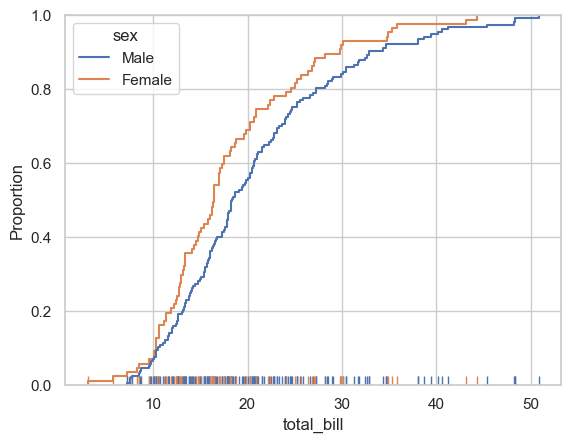

In [15]:
# Empirische Verteilungsfunktion (ECDF)
sns.ecdfplot(data=df, x="total_bill", hue="sex")
# + rugplot
sns.rugplot(data=df, x="total_bill", hue="sex")

#### Streudiagramm & Regression

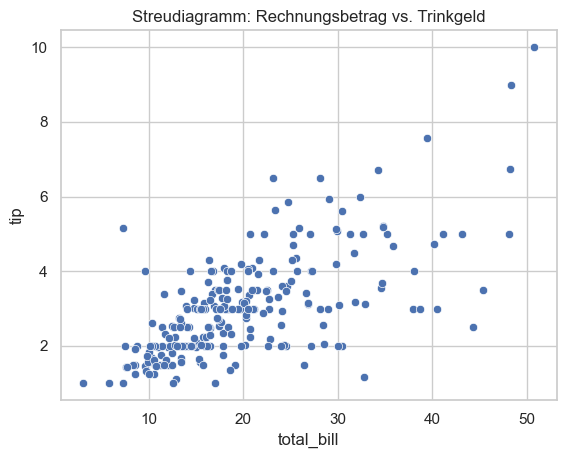

In [17]:
# Streudiagramm für Rechnungsbetrag vs. Trinkgeld

# Erstellen eines Streudiagramms (Scatterplot)
sns.scatterplot(x="total_bill", y="tip", data=df)

# Erklärung:
# x="total_bill" → Die Rechnungsbeträge werden auf der x-Achse dargestellt.
# y="tip" → Die Trinkgelder werden auf der y-Achse dargestellt.
# data=df → Der `tips`-Datensatz wird als Datenquelle verwendet.

# Setzen eines Titels für das Diagramm
plt.title("Streudiagramm: Rechnungsbetrag vs. Trinkgeld")

# Anzeigen des Diagramms
plt.show()

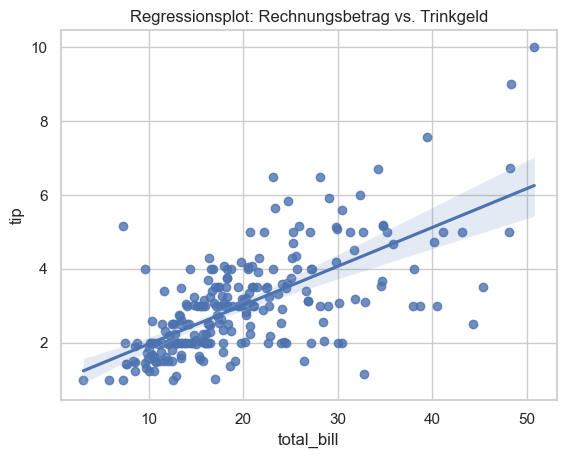

In [18]:
# Erstellen eines Regressionsplots mit Trendlinie
sns.regplot(x="total_bill", y="tip", data=df)

# Der Regressionsplot zeigt die einzelnen Datenpunkte (Streudiagramm)
# und fügt eine lineare Regressionslinie hinzu, um den Trend zwischen den Variablen darzustellen.

# Setzen eines Titels für das Diagramm
plt.title("Regressionsplot: Rechnungsbetrag vs. Trinkgeld")

# Anzeigen des Diagramms
plt.show()

<Figure size 1600x900 with 0 Axes>

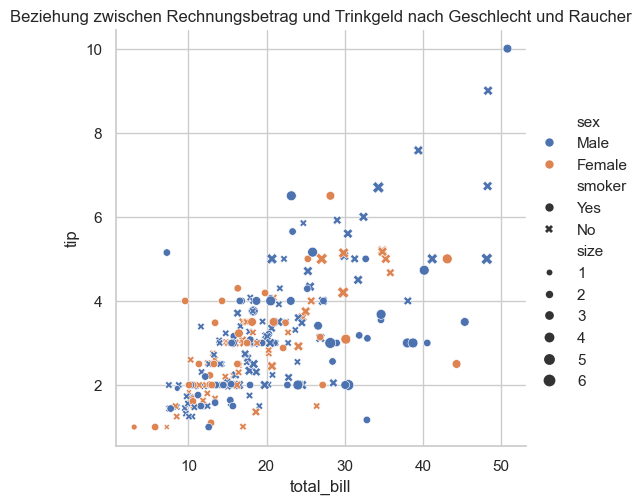

In [19]:
plt.figure(figsize=(16, 9))

# Erstellen eines relationalen Plots (Scatterplot als Standard)
sns.relplot(x="total_bill", y="tip", hue="sex", style="smoker", size="size", data=df)

# Erklärung:
# x="total_bill" → Rechnungsbetrag auf der x-Achse
# y="tip" → Trinkgeld auf der y-Achse
# hue="sex" → Punkte nach Geschlecht farblich unterscheiden
# style="smoker" → Unterschiedliche Markerformen für Raucher/nichtRaucher
# size="size" → Punktgröße basierend auf der Gruppengröße (Anzahl der Gäste)

# Diagramm anzeigen
plt.title("Beziehung zwischen Rechnungsbetrag und Trinkgeld nach Geschlecht und Raucher")
plt.show()

#### Übersicht: Parameter für `sns.relplot()`

Die `relplot()`-Funktion in Seaborn ist eine flexible Methode zur Visualisierung von **Zusammenhängen zwischen Variablen**. Sie kann sowohl **Streudiagramme (`scatter`)** als auch **Liniendiagramme (`line`)** erzeugen.

##### **1️⃣ Grundlegende Parameter**
| Parameter       | Beschreibung | Beispiel |
|----------------|-------------|----------|
| `x`           | Variable für die x-Achse | `x="total_bill"` |
| `y`           | Variable für die y-Achse | `y="tip"` |
| `data`        | DataFrame mit den Daten | `data=df` |
| `kind`        | Art des Plots: `"scatter"` (Standard) oder `"line"` | `kind="line"` |

---

##### **2️⃣ Gruppierungsoptionen (Farbe, Stil, Größe)**
| Parameter     | Beschreibung | Beispiel |
|--------------|-------------|----------|
| `hue`        | Farbunterscheidung nach einer Kategorie | `hue="sex"` |
| `style`      | Unterschiedliche Marker-/Linienstile je Kategorie | `style="smoker"` |
| `size`       | Punktgröße oder Linienbreite nach einer numerischen Variable | `size="size"` |


### Kategorische Plots

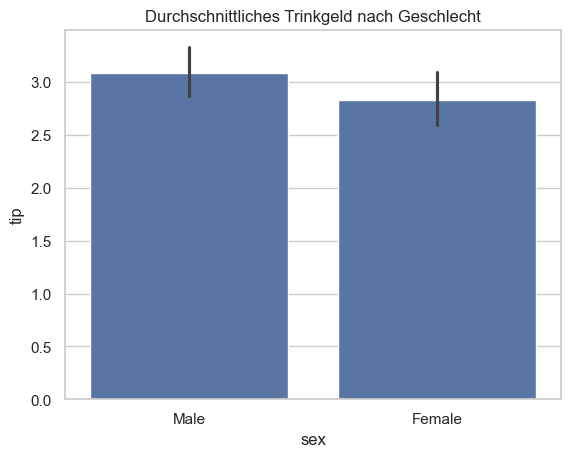

In [22]:
# Balkendiagramm (Durchschnittliches Trinkgeld pro Geschlecht)
sns.barplot(x="sex", y="tip", data=df)
plt.title("Durchschnittliches Trinkgeld nach Geschlecht")
plt.show()

Die **vertikalen Linien** in einem `sns.barplot()` sind **Fehlerbalken**, die standardmäßig die **Standardabweichung (Standard Deviation, STD)** der Daten für jede Kategorie anzeigen.  

- **Balken**: Zeigt den Durchschnittswert (`mean`) des Trinkgelds für jedes Geschlecht.
- **Vertikale Linien** (Fehlerbalken): Standardmäßig die **Standardabweichung** der Trinkgelder innerhalb jeder Geschlechterkategorie.
- Seaborn berechnet diese Werte automatisch.

Falls du stattdessen den **Standardfehler des Mittelwerts (SEM)** oder andere Maße anzeigen möchtest, kannst du das mit dem `errorbar`-Parameter steuern:

<Axes: xlabel='sex', ylabel='tip'>

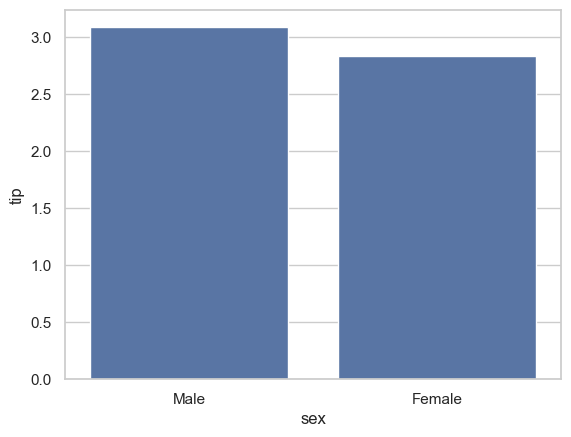

In [24]:
# Balkendiagramm ohne Fehlerbalken
sns.barplot(x="sex", y="tip", data=df, errorbar=None)

Mit <a href="https://seaborn.pydata.org/generated/seaborn.boxplot.html">`boxplot`</a> kann man ein Boxplot der Daten erstellen. Boxplots sind eine wichtige Visualisierung der Verteilung in der Statistik, besonders für kategorische Variablen. 

<Axes: xlabel='sex', ylabel='tip'>

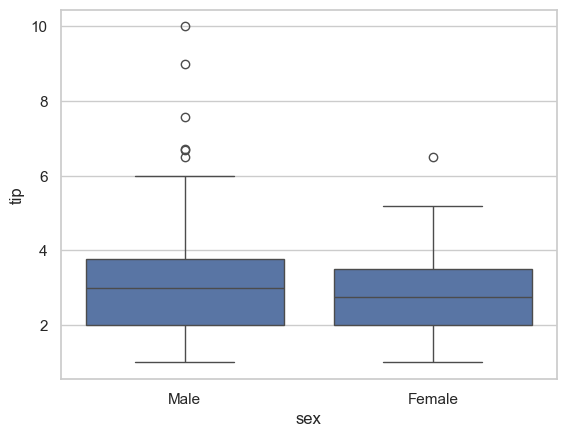

In [26]:
# Boxplot (zeigt Verteilung und Ausreißer)
sns.boxplot(x="sex", y="tip", data=df)

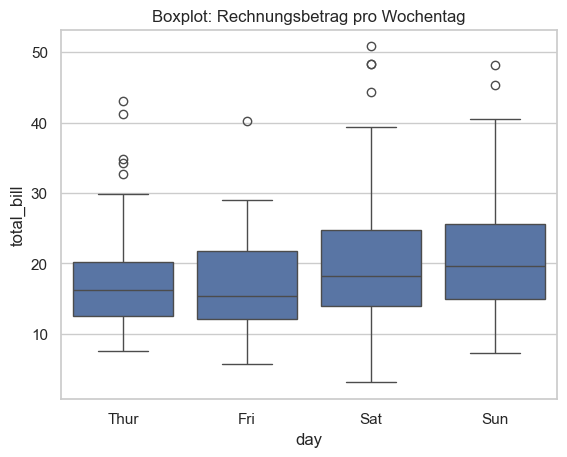

In [27]:
sns.boxplot(x="day", y="total_bill", data=df)
plt.title("Boxplot: Rechnungsbetrag pro Wochentag")
plt.show()

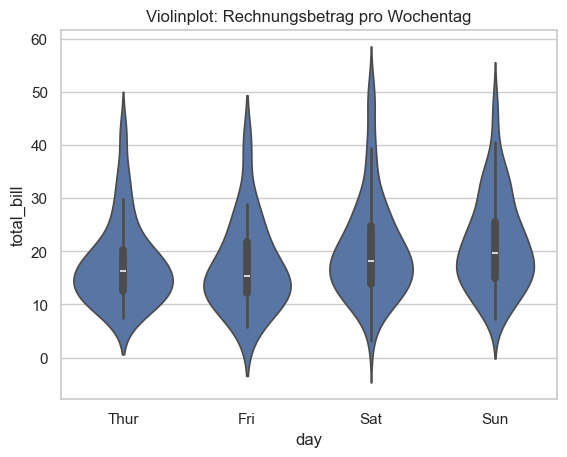

In [28]:
# Violinplot (Kombination aus Boxplot & KDE)
sns.violinplot(x="day", y="total_bill", data=df)
plt.title("Violinplot: Rechnungsbetrag pro Wochentag")
plt.show()

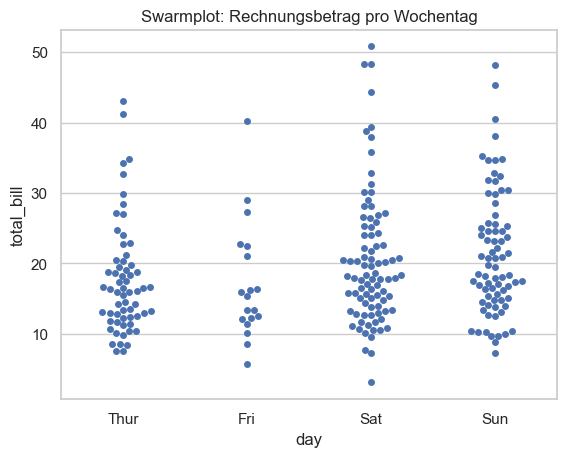

In [29]:
# Swarmplot (jedes Individuum sichtbar)
sns.swarmplot(x="day", y="total_bill", data=df)
plt.title("Swarmplot: Rechnungsbetrag pro Wochentag")
plt.show()

###  Fortgeschrittene Funktionen

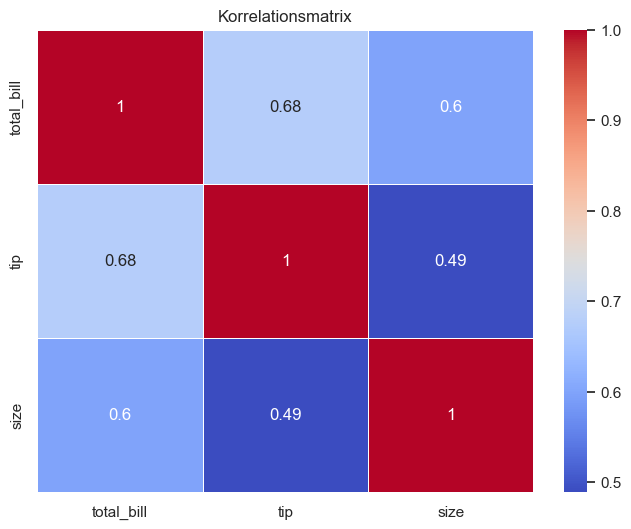

In [31]:
## Heatmap zur Korrelation der numerischen Variablen
# Nur numerische Spalten auswählen
numeric_df = df.select_dtypes(include=["number"])

# Heatmap der Korrelationsmatrix
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

# Titel setzen
plt.title("Korrelationsmatrix")

# Diagramm anzeigen
plt.show()

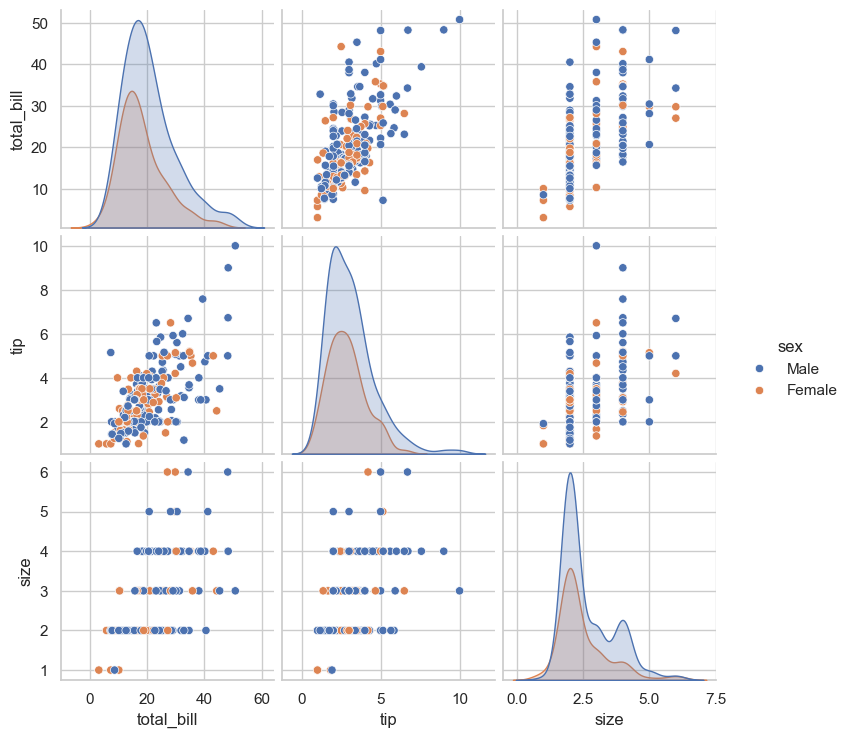

In [32]:
## Pairplot: Überblick über alle Variablenbeziehungen
sns.pairplot(df, hue="sex")  # Farbe nach Geschlecht
plt.show()

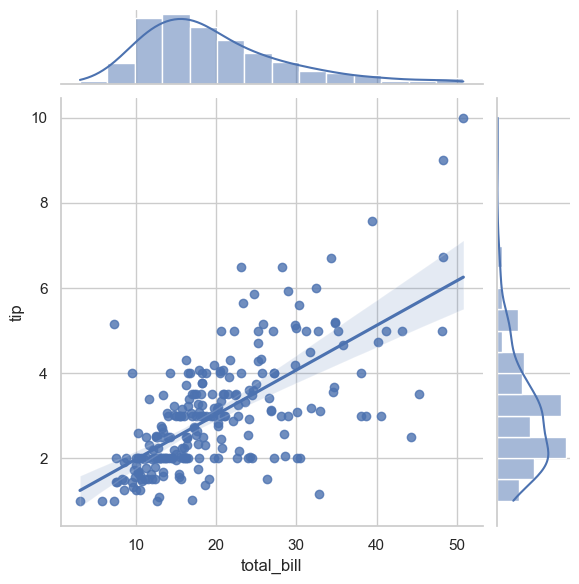

In [33]:
## Jointplot: Zwei Variablen analysieren
sns.jointplot(x="total_bill", y="tip", data=df, kind="reg")
plt.show()

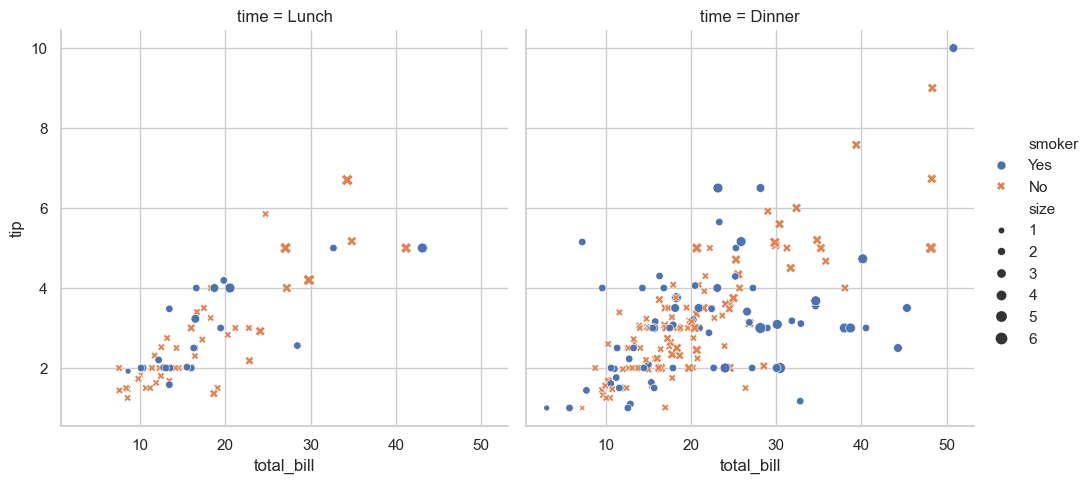

In [34]:
# 4. Gruppieren von Plots

# col bestimmt Gruppen
sns.relplot(
    data=df,
    x="total_bill",
    y="tip",
    col="time",
    hue="smoker",
    style="smoker",
    size="size",
)

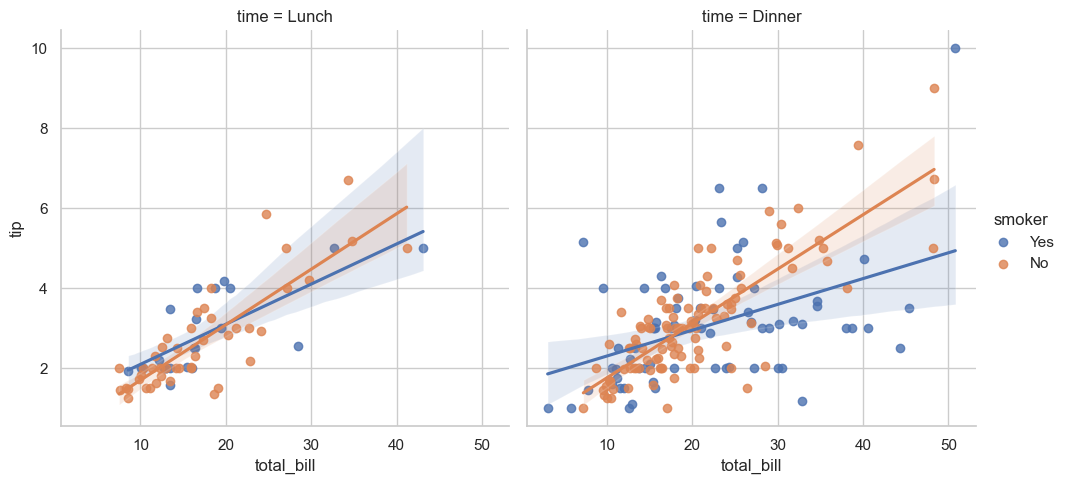

In [35]:
# Die statistische Schätzung in Seaborn geht über die deskriptive Statistik hinaus.
# Zum Beispiel ist es möglich, ein Streudiagramm zu erweitern,
# indem man ein lineares Regressionsmodell (und dessen Unsicherheit) mit lmplot() einfügt.

sns.lmplot(data=df, x="total_bill", y="tip", col="time", hue="smoker")